In [ ]:
import pandas as pd

top_matches_FaceNet512_df = pd.read_csv('data/top_matches_Facenet512_euclidean_l2_0.csv')

----
## Update für Posts: Erstelle `all_faces_df`

In [ ]:
import pandas as pd
import json

# Function to read JSON data from a file
def read_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Example usage
wo_reviews_file_path = 'data/2024-06-14-Post-Gesichter-Annotationen-w-o-reviews.json' #'data/2024-06-14-Post-Gesichter-Annotationen-w-reviews.json'
w_reviews_file_path = 'data/2024-06-14-Post-Gesichter-Annotationen-w-reviews.json'

data_w_review = read_json_file(w_reviews_file_path)
data_wo_review = read_json_file(wo_reviews_file_path)

In [ ]:
matching_items = [item for item in data_w_review if "abaerbock/2021-09-14_10-00-20_UTC_1.jpg" in item.get('data', {}).get('image', '').replace("../data/", "")]

In [ ]:
print(json.dumps(matching_items[0]))

In [ ]:
print(json.dumps(data_w_review[600]))

In [ ]:
from tqdm.notebook import tqdm

def process_results(results, annotator_id, image):
    for result in results:
        if result['type'] == "rectangle":
            rectangles.append({
                "uuid": result['id'],
                "image": image
            })
        elif result['type'] == "labels":
            labels.append({
                "uuid": result['id'],
                "image": image,
                "annotator": annotator_id,
                "value": result['value']['labels'][0]
            })
            print(f"Added Review by {annotator_id}, result {result['id']}")
        else:
            labels.append({
                "uuid": result['id'],
                "image": image,
                "annotator": annotator_id,
                "value": "Unknown"
            })

def merge_results(original_results, review_results):
    merged = {result['id']: result for result in original_results}

    if review_results:
        for review_result in review_results:
            merged[review_result['id']] = review_result

    return list(merged.values())

rectangles = []
labels = []
reviewd_rows = []

for item in tqdm(data_w_review):
    annotations = item.get('annotations', [])
    image_path = item.get('data', {}).get('image', '').replace("../data/", "")

    for annotation in annotations:
        original_results = annotation.get('result', [])
        reviews = annotation.get("reviews", [])

        if reviews:
            review = reviews[-1]  # Get the latest review
            reviewer = review.get('created_by', {}).get('id', 'Unknown')
            review_results = review.get('result', [])

            if review_results:
              print(json.dumps(review_results))

            previous_results = review.get('previous_annotation_history_result', [])

            # Merge original results with review results
            merged_results = merge_results(previous_results, review_results)

            # Process the merged results
            process_results(merged_results, reviewer, image_path)

In [ ]:
from tqdm.notebook import tqdm

rectangles = []
labels = []

for item in tqdm(data_wo_review):
  annotations = item.get('annotations')
  predictions = item.get('predictions', {})

  for annotation in annotations:
    for result in annotation.get('result',[]):
      if result['type'] == "rectangle":
        rectangles.append({
            "uuid": result['id'],
            "image": item.get('data').get('image').replace("../data/","")
            })

      if result['type'] == "labels":
        labels.append({
            "uuid": result['id'],
            "image": item.get('data').get('image').replace("../data/",""),
            "annotator": annotation['completed_by']['id'],
            "value": result['value']['labels'][0]
        })

      else:
        labels.append({
            "uuid": result['id'],
            "image": item.get('data').get('image').replace("../data/",""),
            "annotator": annotation['completed_by']['id'],
            "value": "Unknown"
        })


In [ ]:
# Convert the labels list to a DataFrame
labels_df = pd.DataFrame(labels)

# Remove duplicates by grouping and concatenating values if necessary
labels_df = labels_df.groupby(['uuid', 'annotator', 'image'])['value'].apply(lambda x: ', '.join(x)).reset_index()

# Pivot the DataFrame to get the desired format
result_df = labels_df.pivot(index=['uuid', 'image'], columns='annotator', values='value')

# Reset the index to ensure 'uuid' and 'image' are columns
result_df = result_df.reset_index()

# Ensure all uuids from rectangles are included
all_uuids = pd.DataFrame(rectangles)

# Merge with rectangles DataFrame on 'uuid'
result_df = pd.merge(all_uuids, result_df, on=['uuid', 'image'], how='left')

# Fill NaN values with an appropriate placeholder if needed, e.g., ''
result_df = result_df.fillna('')

result_df = result_df.drop_duplicates(subset=['uuid'])

In [ ]:
result_df

,uuid,image,7107,17607,20479,20817
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,gs://ig-politik-posts/olafscholz/2021-09-13_07...,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",,
2,d83b5202-1f81-4b16-b8c8-360f0e6051e5,gs://ig-politik-posts/olafscholz/2021-09-14_10...,Unknown,Unknown,,
3,95c9174b-5389-4ccb-89ac-98de4be55d9e,gs://ig-politik-posts/olafscholz/2021-09-14_10...,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",,
6,2d573a4a-21f5-464f-aef4-8700597752c1,gs://ig-politik-posts/olafscholz/2021-09-17_10...,,Unknown,Unknown,
7,3539ae42-9adf-4733-a703-024b662d8eff,gs://ig-politik-posts/olafscholz/2021-09-17_10...,,Unknown,Unknown,
...,...,...,...,...,...,...
7421,cf7c0bba-98ce-4ec5-bb5e-955b2857acdb,gs://ig-politik-posts/spdde/2021-09-16_16-07-3...,,Unknown,Unknown,
7422,a003dd1e-c187-4cf9-a1b3-0d4698534cba,gs://ig-politik-posts/spdde/2021-09-16_16-07-3...,,Unknown,Unknown,
7443,34cbdd3a-85ae-428d-8ceb-a2be90a37dd7,gs://ig-politik-posts/spdde/2021-09-22_18-00-3...,,"Unknown, Olaf Scholz","Unknown, Olaf Scholz",
7444,37691edd-0994-4df0-9702-76b065eda356,gs://ig-politik-posts/spdde/2021-09-22_18-00-3...,,Unknown,Unknown,


In [ ]:
import numpy as np

result_df.replace('', np.nan, inplace=True)

In [ ]:
result_df = result_df.rename(columns={'image': 'filename'})

In [ ]:
result_df.to_csv('data/2024-07-12-Annotations-Posts-Faces-wo-review.csv', index=False)

In [ ]:
result_df.to_csv('data/2024-07-12-Annotations-Posts-Faces-w-review.csv', index=False)

In [ ]:
# Find UUIDs with non-matching annotations, ignoring empty strings
def has_non_matching_annotations(row):
    values = row.dropna().replace('', pd.NA).dropna()
    return len(set(values)) > 3

result_df['Match'] = result_df.apply(has_non_matching_annotations, axis=1)

In [ ]:
result_df[result_df['Match'] == True]

,uuid,image,7107,17607,20479,20817,Match
375,81a0b5c8-95f4-42be-bb93-2d6d158c0e66,gs://ig-politik-posts/olafscholz/2021-09-18_20...,,Unknown,"Unknown, Olaf Scholz",,True
387,363f0406-a4a0-4836-9e99-d863e079079f,gs://ig-politik-posts/olafscholz/2021-09-24_17...,,"Unknown, Saskia Esken",Unknown,,True
557,49624413-4f06-4d77-90e8-4bfc0a52f6ff,gs://ig-politik-posts/robert.habeck/2021-09-15...,,Unknown,"Unknown, Robert Habeck",,True
564,03dc5786-6ddc-4d8e-92fc-345037e2249f,gs://ig-politik-posts/robert.habeck/2021-09-16...,,"Unknown, Robert Habeck",Unknown,,True
1182,5f05f791-aaba-49c4-be68-c62b76f79b2c,gs://ig-politik-posts/robert.habeck/2021-09-21...,,"Unknown, Robert Habeck",Unknown,,True
1313,eecf0dd8-447a-4e81-ba09-fa237c3f1d9f,gs://ig-politik-posts/robert.habeck/2021-09-14...,,"Unknown, Robert Habeck",Unknown,,True
1410,b6d50cf0-979b-4bbe-8cda-e55a771810a7,gs://ig-politik-posts/robert.habeck/2021-09-23...,,"Unknown, Robert Habeck",Unknown,,True
1470,b7e00a2a-02d5-4123-860b-af8fe76bc5bc,gs://ig-politik-posts/cdu/2021-09-21_18-48-32_...,,Unknown,"Unknown, Armin Laschet",,True
1527,3c39abe0-1ef1-4459-84dd-8e0d57e8b7bf,gs://ig-politik-posts/cdu/2021-09-21_20-02-32_...,,"Unknown, Olaf Scholz","Unknown, Armin Laschet",,True
1752,b48a69cb-dcea-4e35-9d93-185518ea5ccf,gs://ig-politik-posts/cdu/2021-09-24_19-39-33_...,,"Unknown, Armin Laschet",Unknown,,True


In [ ]:
# Define a function to find the first non-empty string in a row
def create_label(row):
    names = set()

    for annotator in row[[7107, 17607, 20479, 20817]]:
      names.add(annotator)

    names = list(names)

    return ''.join(names)

# Apply the function to each row to create the final label column
result_df['final_label'] = result_df.apply(create_label, axis=1)

In [ ]:
result_df

,uuid,image,7107,17607,20479,20817,Match,final_label
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,gs://ig-politik-posts/olafscholz/2021-09-13_07...,Olaf Scholz,Olaf Scholz,,,False,Olaf Scholz
2,d83b5202-1f81-4b16-b8c8-360f0e6051e5,gs://ig-politik-posts/olafscholz/2021-09-14_10...,,,,,False,
3,95c9174b-5389-4ccb-89ac-98de4be55d9e,gs://ig-politik-posts/olafscholz/2021-09-14_10...,Olaf Scholz,Olaf Scholz,,,False,Olaf Scholz
6,2d573a4a-21f5-464f-aef4-8700597752c1,gs://ig-politik-posts/olafscholz/2021-09-17_10...,,,,,False,
7,3539ae42-9adf-4733-a703-024b662d8eff,gs://ig-politik-posts/olafscholz/2021-09-17_10...,,,,,False,
...,...,...,...,...,...,...,...,...
7421,cf7c0bba-98ce-4ec5-bb5e-955b2857acdb,gs://ig-politik-posts/spdde/2021-09-16_16-07-3...,,,,,False,
7422,a003dd1e-c187-4cf9-a1b3-0d4698534cba,gs://ig-politik-posts/spdde/2021-09-16_16-07-3...,,,,,False,
7443,34cbdd3a-85ae-428d-8ceb-a2be90a37dd7,gs://ig-politik-posts/spdde/2021-09-22_18-00-3...,,Olaf Scholz,Olaf Scholz,,False,Olaf Scholz
7444,37691edd-0994-4df0-9702-76b065eda356,gs://ig-politik-posts/spdde/2021-09-22_18-00-3...,,,,,False,


In [ ]:
export_df = result_df[['uuid', 'image', 'final_label']].copy()
export_df = export_df.rename(columns={'uuid': 'id', 'image': 'filename', 'final_label': 'label'})

export_df['filename'] = export_df['filename'].apply(lambda x: x.replace('../data/', ''))

export_df.to_csv('data/2024-06-14-posts-all_faces_labeled.csv', index=False)

In [ ]:
export_df

,id,filename,label
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,olafscholz/2021-09-13_07-45-59_UTC.jpg,Olaf Scholz
2,d83b5202-1f81-4b16-b8c8-360f0e6051e5,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,
3,95c9174b-5389-4ccb-89ac-98de4be55d9e,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,Olaf Scholz
6,2d573a4a-21f5-464f-aef4-8700597752c1,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,
7,3539ae42-9adf-4733-a703-024b662d8eff,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,
...,...,...,...
7421,cf7c0bba-98ce-4ec5-bb5e-955b2857acdb,spdde/2021-09-16_16-07-38_UTC.jpg,
7422,a003dd1e-c187-4cf9-a1b3-0d4698534cba,spdde/2021-09-16_16-07-38_UTC.jpg,
7443,34cbdd3a-85ae-428d-8ceb-a2be90a37dd7,spdde/2021-09-22_18-00-38_UTC_1.jpg,Olaf Scholz
7444,37691edd-0994-4df0-9702-76b065eda356,spdde/2021-09-22_18-00-38_UTC_1.jpg,


----

## Check Interrater Agreement

**Note:** Doesn't make sense with the final curated dataset! (Agreement is perfect^^)

In [ ]:
from sklearn.metrics import cohen_kappa_score
import numpy as np
import itertools


# Replace empty strings with NaN to indicate missing values
test_df = result_df.replace('', np.nan).copy()
test_df = test_df[['uuid', 7107, 17607, 20479, 20817]]

# Prepare a function to calculate pairwise Cohen's Kappa
def pairwise_kappa(df, annotator1, annotator2):
    # Drop rows where either annotator has not annotated
    df_pair = df[[annotator1, annotator2]].dropna()
    print(len(df_pair))

    if df_pair.empty:
        return np.nan  # Return NaN if there are no overlapping annotations

    return cohen_kappa_score(df_pair[annotator1], df_pair[annotator2])

# Get the list of annotators
annotators = test_df.columns[1:]  # Exclude the 'uuid' column

# Calculate pairwise Kappa for each pair of annotators
kappa_results = {}

for annotator1, annotator2 in itertools.combinations(annotators, 2):
    kappa = pairwise_kappa(test_df, annotator1, annotator2)
    kappa_results[(annotator1, annotator2)] = kappa


# Display the results
kappa_df = pd.DataFrame.from_dict(kappa_results, orient='index', columns=['Cohen\'s Kappa'])

print(kappa_df)

21
0
0
325
0
0
                Cohen's Kappa
(7107, 17607)             1.0
(7107, 20479)             NaN
(7107, 20817)             NaN
(17607, 20479)            1.0
(17607, 20817)            NaN
(20479, 20817)            NaN


---

## Preparing the Evaluation

In [ ]:
import pandas as pd

top_matches_FaceNet512_df = pd.read_csv('data/top_matches_Facenet512_euclidean_l2_0.csv')
all_faces_labeled_df = pd.read_csv('data/2024-06-14-posts-all_faces_labeled.csv')
all_faces_df = pd.read_csv('data/2024-03-18-Retina-Face-Posts-Detection.csv')
all_faces_df.rename(columns={'uuid': 'face_uuid'}, inplace=True)

In [ ]:
all_faces_df.head()

,image,type,bucket_url,face_uuid,retina_face_score,facial_area,right_eye,left_eye,nose,mouth_right,...,image_width,image_height,f_pixel_x,f_pixel_y,f_pixel_width,f_pixel_height,f_relativ_x,f_relativ_y,f_relativ_width,f_relativ_height
0,images/armin_laschet/2021-09-22_14-55-06_UTC_2...,Post,gs://ig-politik-posts/armin_laschet/2021-09-22...,1e19a944-ce54-4a50-af5f-1fb26ae46852,0.999463,"[618, 68, 698, 179]","[655.83215, 115.59756]","[687.78125, 116.61998]","[679.88385, 137.47713]","[651.548, 148.28584]",...,1440,856,618,68,80,111,42.916667,7.943925,5.555556,12.967290
1,images/armin_laschet/2021-09-22_14-55-06_UTC_2...,Post,gs://ig-politik-posts/armin_laschet/2021-09-22...,7c50af0d-d49f-4121-921b-173b16eb9a63,0.999458,"[865, 76, 941, 176]","[882.80505, 117.19016]","[918.87573, 113.6915]","[901.9659, 135.02817]","[887.5133, 148.83932]",...,1440,856,865,76,76,100,60.069444,8.878505,5.277778,11.682243
2,images/armin_laschet/2021-09-22_14-55-06_UTC_2...,Post,gs://ig-politik-posts/armin_laschet/2021-09-22...,f0902030-6596-4e02-a702-9ac7c47c5e16,0.999433,"[217, 96, 293, 203]","[247.93494, 139.99324]","[282.4035, 137.506]","[276.23734, 155.95622]","[253.7339, 175.65933]",...,1440,856,217,96,76,107,15.069444,11.214953,5.277778,12.500000
3,images/armin_laschet/2021-09-22_14-55-06_UTC_2...,Post,gs://ig-politik-posts/armin_laschet/2021-09-22...,d4d4e4e0-f05f-47f5-8dc3-754335fd3e62,0.995322,"[418, 111, 460, 165]","[427.0738, 133.0951]","[445.76318, 133.36816]","[434.90997, 144.35779]","[429.42117, 153.67068]",...,1440,856,418,111,42,54,29.027778,12.967290,2.916667,6.308411
4,images/armin_laschet/2021-09-22_14-55-06_UTC_2...,Post,gs://ig-politik-posts/armin_laschet/2021-09-22...,b57bfd65-c875-4f24-9273-ed43955386d2,0.995100,"[986, 65, 1075, 227]","[1001.7438, 125.714874]","[1003.1344, 126.80907]","[987.33704, 157.53435]","[1007.1196, 187.25154]",...,1440,856,986,65,89,162,68.472222,7.593458,6.180556,18.925234


In [ ]:
top_matches_FaceNet512_df.head()

,face_uuid,match_file,match_score,model,distance_metric,number_of_hits
0,be4d0281-00f8-4c08-baf9-eb09fe94338b,5efa5b53-ada6-486e-8b66-4c6330a71ea7.png,0.625114,Facenet512,euclidean_l2,40
1,28fe59b4-68d2-4f47-8678-3391d339074b,9c3a43b8-03a7-453c-a980-1c4523abd5f3.png,0.827469,Facenet512,euclidean_l2,34
2,a1d63d53-4469-47fd-8f77-616751c34660,872af970-553e-4d30-abdc-252f937b8d70.png,0.679570,Facenet512,euclidean_l2,40
3,7234c42e-2b3a-41b1-97f0-d4853882154f,b95e4651-bf56-4f12-8d9c-4defe1aef9b0.png,0.332480,Facenet512,euclidean_l2,40
4,c6d80c20-0813-4022-86ad-8279d02a5739,7cdeee40-f222-4b03-a819-4db32fc47d20.png,0.587585,Facenet512,euclidean_l2,40


In [ ]:
top_matches_FaceNet512_df = top_matches_FaceNet512_df.merge(all_faces_df[['face_uuid']], how="left", on="face_uuid")

In [ ]:
top_matches_FaceNet512_df.head()

,face_uuid,match_file,match_score,model,distance_metric,number_of_hits
0,be4d0281-00f8-4c08-baf9-eb09fe94338b,5efa5b53-ada6-486e-8b66-4c6330a71ea7.png,0.625114,Facenet512,euclidean_l2,40
1,28fe59b4-68d2-4f47-8678-3391d339074b,9c3a43b8-03a7-453c-a980-1c4523abd5f3.png,0.827469,Facenet512,euclidean_l2,34
2,a1d63d53-4469-47fd-8f77-616751c34660,872af970-553e-4d30-abdc-252f937b8d70.png,0.679570,Facenet512,euclidean_l2,40
3,7234c42e-2b3a-41b1-97f0-d4853882154f,b95e4651-bf56-4f12-8d9c-4defe1aef9b0.png,0.332480,Facenet512,euclidean_l2,40
4,c6d80c20-0813-4022-86ad-8279d02a5739,7cdeee40-f222-4b03-a819-4db32fc47d20.png,0.587585,Facenet512,euclidean_l2,40


In [ ]:
all_faces_labeled_df.head()

,id,filename,label
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,olafscholz/2021-09-13_07-45-59_UTC.jpg,Olaf Scholz
1,d83b5202-1f81-4b16-b8c8-360f0e6051e5,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,NaN
2,95c9174b-5389-4ccb-89ac-98de4be55d9e,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,Olaf Scholz
3,2d573a4a-21f5-464f-aef4-8700597752c1,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,NaN
4,3539ae42-9adf-4733-a703-024b662d8eff,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,NaN


In [ ]:
len(all_faces_labeled_df['filename'].unique())

1011

### Lookup Database

In [ ]:
#@title Load an unzip images database
#!unzip -q ../data/2022-08-18-database-final-v3.zip -d ./database_final-v1
!unzip -q ../data/2024-01-03-database-final-v4.zip -d ./database_final-v1

In [ ]:
DATABASE = "/content/database_final-v1/2024-01-03-database-final-v4"

In [ ]:
import os
import unicodedata

def replace_characters(original):
    normalized = unicodedata.normalize('NFC', original)
    # Replace specific characters in the string
    return normalized.replace('ä', 'ae').replace('ö', 'oe').replace('ü', 'ue')

def rename_files_and_folders(path):
    for root, dirs, files in os.walk(path, topdown=False):
        # Rename files
        for name in files:
            new_name = replace_characters(name)
            if new_name != name:
                os.rename(os.path.join(root, name), os.path.join(root, new_name))

        # Rename directories
        for name in dirs:
            new_name = replace_characters(name)
            if new_name != name:
                os.rename(os.path.join(root, name), os.path.join(root, new_name))

rename_files_and_folders(DATABASE)

In [ ]:
employees = []
politicians_list = []

for r, _, f in os.walk(DATABASE):
    for file in f:
        if (
            (".jpg" in file.lower())
            or (".jpeg" in file.lower())
            or (".png" in file.lower())
        ):
            exact_path = r + "/" + file
            employees.append(exact_path)

if len(employees) == 0:
    raise ValueError(
        "There is no image in ",
        DATABASE,
        " folder! Validate .jpg or .png files exist in this path.",
    )

for empl in employees:
  politician = empl.split('/')[4]
  file_name = empl.split('/')[5]

  politicians_list.append((politician, file_name))

politicians_lookup_df = pd.DataFrame(politicians_list, columns =['politician', 'file_name'])

In [ ]:
#politicians_lookup_df.replace(old_value, new_value, inplace=True)

politicians_lookup_df.replace("Markus Soeder", "Markus Söder", inplace=True)
politicians_lookup_df.replace("Joerg Meuthen", "Jörg Meuthen", inplace=True)
politicians_lookup_df.replace("Ates Guerpinar", "Ates Gürpinar", inplace=True)

In [ ]:
politicians_lookup_df

,politician,file_name
0,Markus Söder,49bdb61e-e0b0-4666-9cf0-5c7ab16b2516.png
1,Markus Söder,d58b66d8-f621-4c58-9284-a999f266986a.png
2,Markus Söder,dade5d2a-6e44-4700-a1b0-7a6449735c40.png
3,Markus Söder,af45e70d-e05b-4c1c-89ac-114a74810f45.png
4,Markus Söder,732bdb01-2da9-438e-9b36-04c89ad1eea4.png
...,...,...
108,Susanne Hennig-Wellsow,912abe54-544b-46cc-bf5e-e94fbed9f1ad.png
109,Susanne Hennig-Wellsow,hennig-wellsow_susanne.jpeg
110,Engin Eroglu,engin_eroglu.jpeg
111,Ates Gürpinar,gurpinar_ates.jpeg


## Evaluation

In [ ]:
top_matches_FaceNet512_df

,face_uuid,match_file,match_score,model,distance_metric,number_of_hits
0,be4d0281-00f8-4c08-baf9-eb09fe94338b,5efa5b53-ada6-486e-8b66-4c6330a71ea7.png,0.625114,Facenet512,euclidean_l2,40
1,28fe59b4-68d2-4f47-8678-3391d339074b,9c3a43b8-03a7-453c-a980-1c4523abd5f3.png,0.827469,Facenet512,euclidean_l2,34
2,a1d63d53-4469-47fd-8f77-616751c34660,872af970-553e-4d30-abdc-252f937b8d70.png,0.679570,Facenet512,euclidean_l2,40
3,7234c42e-2b3a-41b1-97f0-d4853882154f,b95e4651-bf56-4f12-8d9c-4defe1aef9b0.png,0.332480,Facenet512,euclidean_l2,40
4,c6d80c20-0813-4022-86ad-8279d02a5739,7cdeee40-f222-4b03-a819-4db32fc47d20.png,0.587585,Facenet512,euclidean_l2,40
...,...,...,...,...,...,...
498,790cb392-6f03-46f6-bf95-f9bcecb2fd89,82f4d29e-1d17-4672-b015-52009fda2a23.png,0.913586,Facenet512,euclidean_l2,30
499,765b7293-e057-4a75-a80f-abe62db60502,c27ee252-e37c-4074-92b5-20e300431107.png,0.683576,Facenet512,euclidean_l2,40
500,5acac5b3-75e3-4ac7-9396-ccc17e1f5957,77b54f7d-504a-4313-ab25-b66060e08f06.png,0.432568,Facenet512,euclidean_l2,38
501,028bdc04-759f-4117-9d72-f9d8895d71a3,cf207ba3-2a6b-42b2-b0c6-b0fb9e7532f0.png,0.485264,Facenet512,euclidean_l2,38


In [ ]:
def get_name(filename):
    filtered_df = politicians_lookup_df[politicians_lookup_df['file_name'] == filename]

    if len(filtered_df) > 0:
        return filtered_df['politician'].iloc[0]

    return None

all_faces_labeled_df.rename(columns={'label': 'Ground Truth', 'id': 'face_uuid'}, inplace=True)
top_matches_FaceNet512_df = pd.merge(all_faces_labeled_df, top_matches_FaceNet512_df, on="face_uuid", how="left")
top_matches_FaceNet512_df['Model'] = top_matches_FaceNet512_df['match_file'].apply(get_name)

In [ ]:
top_matches_FaceNet512_df['account_name'] = top_matches_FaceNet512_df['filename'].apply(lambda x: x.split('/')[0])

In [ ]:
top_matches_FaceNet512_df.head()

,face_uuid,filename,Ground Truth,match_file,match_score,model,distance_metric,number_of_hits,Model,account_name
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,olafscholz/2021-09-13_07-45-59_UTC.jpg,Olaf Scholz,addb18d2-ca87-4104-b149-5ecb974f1432.png,0.520983,Facenet512,euclidean_l2,40.0,Olaf Scholz,olafscholz
1,d83b5202-1f81-4b16-b8c8-360f0e6051e5,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,NaN,NaN,NaN,NaN,NaN,NaN,None,olafscholz
2,95c9174b-5389-4ccb-89ac-98de4be55d9e,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,Olaf Scholz,fb89d12e-d3a5-48c2-b506-eca8454e847b.png,0.547668,Facenet512,euclidean_l2,40.0,Olaf Scholz,olafscholz
3,2d573a4a-21f5-464f-aef4-8700597752c1,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,NaN,NaN,NaN,NaN,NaN,NaN,None,olafscholz
4,3539ae42-9adf-4733-a703-024b662d8eff,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,NaN,NaN,NaN,NaN,NaN,NaN,None,olafscholz


In [ ]:
len(top_matches_FaceNet512_df['filename'].unique())

1011

Next, let's filter for the relevant accounts and names: Top-Candidates & Selected parties.

In [ ]:
# Ich arbeite jetzt nur mit den Kanzlerkandidaten Accounts damit als erstes diesen Filter
selected_accounts = ['armin_laschet', 'abaerbock', 'christlichsozialeunion',
       'christianlindner', 'cdu', 'fdp', 'die_gruenen', 'markus.soeder',
       'spdde', 'olafscholz']

top_matches_FaceNet512_df = top_matches_FaceNet512_df[top_matches_FaceNet512_df['account_name'].isin(selected_accounts)]

In [ ]:
len(top_matches_FaceNet512_df['filename'].unique())

735

In [ ]:
#accounts_dict = {
#  "armin_laschet": ["Armin Laschet"],
#  "spdde": ["Olaf Scholz"],
#  "christianlindner": ["Christian Lindner"],
#  "abaerbock": ["Annalena Baerbock"],
#  "cdu": ["Armin Laschet"],
#  "olafscholz": ["Olaf Scholz"],
#  "die_gruenen": ["Annalena Baerbock"],
#  "christlichsozialeunion": ["Markus Söder"],
#  "fdp": ["Christian Lindner"],
#  "markus.soeder":  ["Markus Söder"],
#}

###### 2024-10-30 Erstelle nochmal eine vollständige Liste

accounts_dict = {
  "armin_laschet": ["Armin Laschet", "Markus Söder"],
  "spdde": ["Olaf Scholz", "Saskia Esken"],
  "afd.bund": ["Alice Weidel", "Jörg Meuthen"],
  "nicola_beer": ["Christian Lindner", "Nicola Beer"],
  "christianlindner": ["Christian Lindner", "Nicola Beer"],
  "abaerbock": ["Annalena Baerbock", "Robert Habeck"],
  "cdu": ["Markus Söder", "Armin Laschet"],
  "robert.habeck": ["Robert Habeck", "Annalena Baerbock"],
  "olafscholz": ["Olaf Scholz", "Saskia Esken"],
  "fw_bayern": ["Gregor Voht", "Engin Eroglu"],
  "die_gruenen": ["Robert Habeck", "Annalena Baerbock"],
  "christlichsozialeunion": ["Markus Söder", "Armin Laschet"],
  "fdp": ["Christian Lindner", "Nicola Beer"],
  "saskiaesken": ["Olaf Scholz", "Saskia Esken"],
  "susanne_hennig_wellsow": ["Susanne Hennig-Wellsow", "Ates Gürpinar"],
  "atesgurpinar":  ["Susanne Hennig-Wellsow", "Ates Gürpinar"],
  "grey_gor": ["Gregor Voht", "Engin Eroglu"],
  "markus.soeder":  ["Markus Söder", "Armin Laschet"],
  "dielinke":  ["Susanne Hennig-Wellsow", "Ates Gürpinar"],
  "joerg.meuthen":["Alice Weidel", "Jörg Meuthen"],
  "engin_eroglu_": ["Gregor Voht", "Engin Eroglu"]
}

In [ ]:
# Function to check if the model is in the list for the account_name
def check_model(row, col, accounts_dict):
    # Get the list of valid models for the account_name
    valid_models = accounts_dict.get(row['account_name'], [])

    # Return 'Unknown' if the model is not in the list, else return the model
    return row[col] if row[col] in valid_models else 'Unknown'

# Function to normalize unicode strings to NFC
def normalize_unicode(text):
    if text:
      return unicodedata.normalize('NFC', text)

    else:
      return None

# Apply the function to each row of the DataFrame
df_filtered = top_matches_FaceNet512_df.copy()
df_filtered['Model'] = df_filtered['Model'].apply(normalize_unicode)
df_filtered['Model'] = df_filtered.apply(lambda row: check_model(row, "Model", accounts_dict), axis=1)
df_filtered['Ground Truth'] = df_filtered.apply(lambda row: check_model(row, "Ground Truth", accounts_dict), axis=1)

In [ ]:
df_filtered

,face_uuid,filename,Ground Truth,match_file,match_score,model,distance_metric,number_of_hits,Model,account_name
0,b248b1d2-1780-4b4c-8529-571b0246a9e5,olafscholz/2021-09-13_07-45-59_UTC.jpg,Olaf Scholz,addb18d2-ca87-4104-b149-5ecb974f1432.png,0.520983,Facenet512,euclidean_l2,40.0,Olaf Scholz,olafscholz
1,d83b5202-1f81-4b16-b8c8-360f0e6051e5,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,Unknown,NaN,NaN,NaN,NaN,NaN,Unknown,olafscholz
2,95c9174b-5389-4ccb-89ac-98de4be55d9e,olafscholz/2021-09-14_10-23-23_UTC_1.jpg,Olaf Scholz,fb89d12e-d3a5-48c2-b506-eca8454e847b.png,0.547668,Facenet512,euclidean_l2,40.0,Olaf Scholz,olafscholz
3,2d573a4a-21f5-464f-aef4-8700597752c1,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,Unknown,NaN,NaN,NaN,NaN,NaN,Unknown,olafscholz
4,3539ae42-9adf-4733-a703-024b662d8eff,olafscholz/2021-09-17_10-42-46_UTC_2.jpg,Unknown,NaN,NaN,NaN,NaN,NaN,Unknown,olafscholz
...,...,...,...,...,...,...,...,...,...,...
5205,cf7c0bba-98ce-4ec5-bb5e-955b2857acdb,spdde/2021-09-16_16-07-38_UTC.jpg,Unknown,NaN,NaN,NaN,NaN,NaN,Unknown,spdde
5206,a003dd1e-c187-4cf9-a1b3-0d4698534cba,spdde/2021-09-16_16-07-38_UTC.jpg,Unknown,NaN,NaN,NaN,NaN,NaN,Unknown,spdde
5207,34cbdd3a-85ae-428d-8ceb-a2be90a37dd7,spdde/2021-09-22_18-00-38_UTC_1.jpg,Olaf Scholz,8c8b42f9-47e7-4df5-bffb-da674eab6953.png,0.937010,Facenet512,euclidean_l2,32.0,Olaf Scholz,spdde
5208,37691edd-0994-4df0-9702-76b065eda356,spdde/2021-09-22_18-00-38_UTC_1.jpg,Unknown,NaN,NaN,NaN,NaN,NaN,Unknown,spdde


In [ ]:
len(df_filtered['filename'].unique())

1011

In [ ]:
len(df_filtered[df_filtered['Ground Truth'] != "Unknown"]['filename'].unique())

479

In [ ]:
df_filtered.to_csv('data/2024-07-03-Faces-in-Posts-unfiltered.csv')

In [ ]:
df_filtered.to_csv('data/2024-10-30-ALL-Faces-in-Posts-unfiltered.csv')

In [ ]:
df_filtered[df_filtered['Ground Truth'] != "Unknown"].to_csv('data/2024-07-01-Faces-in-Posts-filtered.csv')

Calculate Metrics

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

def get_f1(input, threshold = None, avg_val = 'macro'):
  filtered_df = input.copy()

  if threshold is not None:
    filtered_df.loc[filtered_df['match_score'] > threshold, 'Model'] = "Unknown"

  y_true = np.array(filtered_df['Ground Truth']).astype(str)  # Convert to integer if they are categorical
  y_pred = np.array(filtered_df['Model']).astype(str)

  return f1_score(y_true, y_pred, average = avg_val)

Find best threshold

In [ ]:
for threshold in np.arange(0.91, 0.95, .001):
  print(f"Threshold: {threshold}")
  print(get_f1(df_filtered, threshold, 'macro'))
  # print(get_f1(top_matches_MagFace_df, threshold, 'macro'))

Threshold: 0.91
0.8755964006030124
Threshold: 0.911
0.8751536061187123
Threshold: 0.912
0.8751536061187123
Threshold: 0.913
0.8768893929381623
Threshold: 0.914
0.8782292931074608
Threshold: 0.915
0.8782292931074608
Threshold: 0.916
0.8782292931074608
Threshold: 0.917
0.8782292931074608
Threshold: 0.918
0.878800072277696
Threshold: 0.919
0.8799322484801867
Threshold: 0.92
0.8799322484801867
Threshold: 0.921
0.8796409637640972
Threshold: 0.922
0.8796409637640972
Threshold: 0.923
0.8815941313212597
Threshold: 0.924
0.8815941313212597
Threshold: 0.925
0.8815941313212597
Threshold: 0.926
0.8839596852400015
Threshold: 0.927
0.8839596852400015
Threshold: 0.928
0.8839596852400015
Threshold: 0.929
0.8856655066554944
Threshold: 0.93
0.8856655066554944
Threshold: 0.931
0.8847935542464245
Threshold: 0.932
0.8866116215767833
Threshold: 0.933
0.8866116215767833
Threshold: 0.934
0.8872574745027692
Threshold: 0.935
0.8872574745027692
Threshold: 0.936
0.8877158228146383
Threshold: 0.937
0.8867683296372

Plot Confusion Matrix

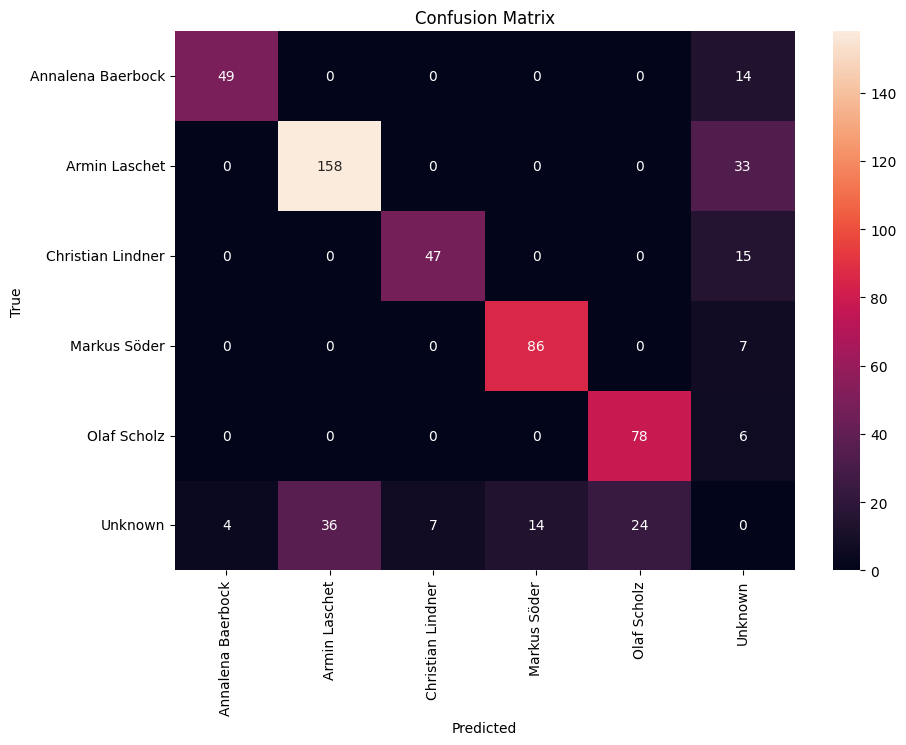

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Your DataFrame 'df' goes here

def get_labels(input_df, threshold=None):
    filtered_df = input_df.copy()

    if threshold is not None:
        filtered_df.loc[filtered_df['match_score'] > threshold, 'Model'] = "Unknown"

    filtered_df['Ground Truth'] = filtered_df['Ground Truth'].fillna("Unknown")
    filtered_df['Model'] = filtered_df['Model'].fillna("Unknown")

    filtered_df = filtered_df[~(filtered_df['Model'].str.strip() == "Unknown") | ~(filtered_df['Ground Truth'].str.strip() == "Unknown")]

    y_true = np.array(filtered_df['Ground Truth']).astype(str)
    y_pred = np.array(filtered_df['Model']).astype(str)

    return y_true, y_pred

y_true, y_pred = get_labels(df_filtered) #, 0.941)

# Get unique labels
labels = np.unique(np.concatenate((y_true, y_pred)))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Improved Reporting

In [ ]:
get_f1(df_filtered)

0.8636985638779614

In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd

def get_f1(input_df, threshold=None, average='macro'):
    filtered_df = input_df.copy()

    if threshold is not None:
        filtered_df.loc[filtered_df['match_score'] > threshold, 'Model'] = "Unknown"

    y_true = np.array(filtered_df['Ground Truth']).astype(str)
    y_pred = np.array(filtered_df['Model']).astype(str)

    return f1_score(y_true, y_pred, average=average)

# Assuming df_filtered is your dataframe
threshold_scores = {}
for threshold in np.arange(0.8, 1.1, .001):
    f1 = get_f1(df_filtered, threshold, 'macro')
    threshold_scores[threshold] = f1

# Identify the optimal threshold
optimal_threshold = max(threshold_scores, key=threshold_scores.get)
optimal_f1 = threshold_scores[optimal_threshold]

print(f"Optimal Threshold: {optimal_threshold} with F1 Score: {optimal_f1}")

# Generate a full report at this threshold
df_filtered.loc[df_filtered['match_score'] > optimal_threshold, 'Model'] = "Unknown"
y_true = np.array(df_filtered['Ground Truth']).astype(str)
y_pred = np.array(df_filtered['Model']).astype(str)

print("Classification Report:")
print(classification_report(y_true, y_pred))

Optimal Threshold: 0.9410000000000002 with F1 Score: 0.890042699686183
Classification Report:
                   precision    recall  f1-score   support

Annalena Baerbock       0.92      0.78      0.84        63
    Armin Laschet       0.94      0.80      0.86       191
Christian Lindner       1.00      0.69      0.82        62
     Markus Söder       0.99      0.86      0.92        93
      Olaf Scholz       0.93      0.89      0.91        84
          Unknown       0.97      0.99      0.98      3386

         accuracy                           0.97      3879
        macro avg       0.96      0.84      0.89      3879
     weighted avg       0.97      0.97      0.97      3879



In [ ]:
!unzip -q ../data/insta-story-images.zip -d ./images

In [ ]:
from IPython.display import Image, display
from PIL import Image as PILImage


for person in df_filtered['Ground Truth'].unique():
    sample = df_filtered[(df_filtered['Ground Truth'] == person) & (df_filtered['Ground Truth'] != df_filtered['Model'])].sample(1)

    for _, row in sample.iterrows():
        filename = f"/content/images/upload_s3/{row['filename']}"

        print(f"Filename: {row['filename']}")
        print(f"Model: {row['Model']}")
        print(f"Human: {row['Ground Truth']}")

        # Assuming the filename is a valid path to the image
        display(PILImage.open(filename))


## Check the total numbers

In [ ]:
import pandas as pd

df = pd.read_csv('data/2023-11-02-story-metadata.csv')

In [ ]:
df.head()

,Unnamed: 0,username,id,__typename,fact_check_information,is_video,has_audio,taken_at_timestamp,expiring_at_timestamp,taken_at_utc,...,tappable_objects,mentions,locations,hashtags,fallback,filename,original_file,poll_question,poll_option_a,poll_option_b
0,0,armin_laschet,2661733359866332931,GraphStoryVideo,NaN,True,True,1631523361,1631609761,2021-09-13 08:56:01,...,"GraphTappableMention, GraphTappableMention, Gr...","cdunrw, ardmoma, cdu, connectcdu",NaN,NaN,NaN,armin_laschet_14-09-2021_00:00_video0.jpeg,armin_laschet_14-09-2021_00:00_item0.json,NaN,NaN,NaN
1,1,abaerbock,2661953998771199439,GraphStoryImage,NaN,False,NaN,1631549663,1631636063,2021-09-13 16:14:23,...,"GraphTappableLocation, GraphTappableStoryPoll",NaN,1.019083e+09,NaN,NaN,abaerbock_14-09-2021_00:00_image0.jpeg,abaerbock_14-09-2021_00:00_item0.json,NaN,🥨,🍺
2,2,christlichsozialeunion,2661727205849745794,GraphStoryVideo,NaN,True,False,1631522628,1631609028,2021-09-13 08:43:48,...,GraphTappableFeedMedia,NaN,NaN,NaN,NaN,christlichsozialeunion_14-09-2021_00:00_video0...,christlichsozialeunion_14-09-2021_00:00_item0....,NaN,NaN,NaN
3,3,fw_bayern,2661627511706428192,GraphStoryImage,NaN,False,NaN,1631510741,1631597141,2021-09-13 05:25:41,...,GraphTappableMention,florian_lichtenstern,NaN,NaN,NaN,fw_bayern_14-09-2021_00:00_image0.jpeg,fw_bayern_14-09-2021_00:00_item0.json,NaN,NaN,NaN
4,4,christianlindner,2661690899433534754,GraphStoryImage,NaN,False,NaN,1631518298,1631604698,2021-09-13 07:31:38,...,"GraphTappableHashtag, GraphTappableHashtag, Gr...",fdp,NaN,"tvtipp, triell",NaN,christianlindner_14-09-2021_00:00_image0.jpeg,christianlindner_14-09-2021_00:00_item0.json,NaN,NaN,NaN


In [ ]:
# Ich arbeite jetzt nur mit den Kanzlerkandidaten Accounts damit als erstes diesen Filter
selected_accounts = ['armin_laschet', 'abaerbock', 'christlichsozialeunion',
       'christianlindner', 'cdu', 'fdp', 'die_gruenen', 'markus.soeder',
       'spdde', 'olafscholz']

filtered_df = df[df['username'].isin(selected_accounts)]

In [ ]:
len(filtered_df)

1424